# Construcción de una capa de extracción de características basada en heurística

In [1]:
from google.colab import drive
drive.mount('/content/drive')
DATASET_PATH = '/content/drive/MyDrive/TFG_Posdata/datasets/dataset_final.csv'

Mounted at /content/drive


In [10]:
import pandas as pd
import numpy as np
import sklearn
import lightgbm as lgb
import shap
import joblib
import re

df = pd.read_csv(DATASET_PATH)
assert df['text'].notna().all(), 'La columna text contiene valores nulos'
assert df['label'].notna().all(), 'La columna label contiene valores nulos'

In [11]:
urgency_words = ['urgente','urgently','urgent','inmediatamente','immediately',
                   'ahora','now','hoy','today','bloquea','blocked','suspendida',
                   'suspended','cancel','cancela','verifique','verify']
action_words = ['haga clic','click','acceda','access','llame','call','responda',
                   'reply','confirme','confirm','descargue','download','ingrese','enter']
financial_words = ['cuenta','account','banco','bank','tarjeta','card','pago','payment',
                   'transferencia','transfer','bizum','credito','credit','débito','debit']
prize_words = ['gratis','free','premio','prize','ganador','winner','regalo','gift',
                   'oferta','offer','descuento','discount','gana','win']
threat_words = ['amenaza', 'threat', 'peligro', 'danger', 'dangerous', 'peligroso', 'cuidado',
                'beware', 'attention', 'atencion', 'careful', 'cuidado']
impersonation_words = [
    # Bancos
    "santander", "bbva", "caixabank", "bankinter", "sabadell",
    "bankia", "ing", "kutxabank", "ibercaja", "unicaja",
    "abanca", "cajamar", "openbank", "bizum",
    # Operadoras
    "movistar", "vodafone", "orange", "masmovil", "yoigo",
    "jazztel", "lowi",
    # Envíos
    "correos", "seur", "mrw", "dhl", "fedex", "ups", "gls", "celeritas",
    # Instituciones
    "hacienda", "tributaria", "dgt", "sepe", "ministerio",
    "ayuntamiento", "policia", "guardia civil", "seguridad social",
    # Servicios digitales
    "apple", "google", "microsoft", "netflix", "spotify",
    "whatsapp", "facebook", "instagram", "icloud",
    # Compras
    "mercadona", "lidl", "carrefour", "alcampo", "aldi",
    "zara", "inditex", "repsol", "bp", "iberdrola", "endesa", "naturgy",
]

_http_pattern = r"https?://[^\s]+"
_www_pattern = r"www\.[^\s]+"
url_pattern     = re.compile(f"({_http_pattern})|({_www_pattern})")
shortener_pattern = re.compile(r'\b(bit\.ly|t\.co|tinyurl\.com|goo\.gl|ow\.ly|rb\.gy|cutt\.ly)\b')
phone_pattern   = re.compile(r'(\+?[1-9]\d{1,14}|[0-9]{9,15})')

def extract_features (df):
  numeric_df = pd.DataFrame()

  #Features estructurales
  numeric_df['text_len'] = df['text'].str.len()
  numeric_df['word_count'] = df['text'].str.split().str.len()
  numeric_df['avg_word_len'] = numeric_df['text_len'] / numeric_df['word_count'].replace(0, 1)
  numeric_df['caps_ratio'] = df['text'].apply(lambda x: sum(1 for c in x if c.isupper())/max(len(x), 1))
  numeric_df['digit_ratio'] = df['text'].apply(lambda x: sum(1 for c in x if c.isdigit())/max(len(x), 1))
  numeric_df['excl_count'] = df['text'].str.count('!')
  numeric_df['ques_count'] = df['text'].str.count(r'\?')
  numeric_df['num_count'] = df['text'].str.count(r'\d')

  #Features semánticas
  numeric_df['has_urgency'] = df['text'].apply(lambda t: any(w in str(t).lower() for w in urgency_words))
  numeric_df['has_action'] = df['text'].apply(lambda t: any(w in str(t).lower() for w in action_words))
  numeric_df['has_financial'] = df['text'].apply(lambda t: any(w in str(t).lower() for w in financial_words))
  numeric_df['has_prize'] = df['text'].apply(lambda t: any(w in str(t).lower() for w in prize_words))
  numeric_df['has_threat'] = df['text'].apply(lambda t: any(w in str(t).lower() for w in threat_words))
  numeric_df['has_impersonation'] = df['text'].apply(lambda t: any(w in str(t).lower() for w in impersonation_words))

  #Features de contenido
  numeric_df['has_url'] = df['text'].apply(lambda t: bool(url_pattern.search(str(t))))
  numeric_df['has_phone'] = df['text'].apply(lambda t: bool(phone_pattern.search(str(t))))
  numeric_df['url_len'] = df['text'].apply(lambda t: (m := url_pattern.search(str(t))) and len(m.group(0)) or 0)
  numeric_df['has_shortener'] = df['text'].apply(lambda t: bool(shortener_pattern.search(str(t))))

  return numeric_df

X = extract_features(df)
y = (df['label'] == 'spam').astype(int)

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [17]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print(f'Distribución original con datos sin balancear: {Counter(y_train)}')
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f'Distribución con datos balanceados: {Counter(y_train_resampled)}')

Distribución original con datos sin balancear: Counter({0: 3826, 1: 777})
Distribución con datos balanceados: Counter({0: 3826, 1: 3826})


In [18]:
model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
)

model.fit(
    X_train_resampled, y_train_resampled,
    eval_set=[(X_test, y_test)],
    callbacks=[
        lgb.log_evaluation(period=50),
        lgb.early_stopping(stopping_rounds=50)
    ]
)


[LightGBM] [Info] Number of positive: 3826, number of negative: 3826
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001718 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1169
[LightGBM] [Info] Number of data points in the train set: 7652, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 50 rounds
[50]	valid_0's binary_logloss: 0.129909
[100]	valid_0's binary_logloss: 0.0957365
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, max_depth=6,
               n_estimators=500, subsample=0.8)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       940
           1       0.91      0.92      0.92       211

    accuracy                           0.97      1151
   macro avg       0.95      0.95      0.95      1151
weighted avg       0.97      0.97      0.97      1151



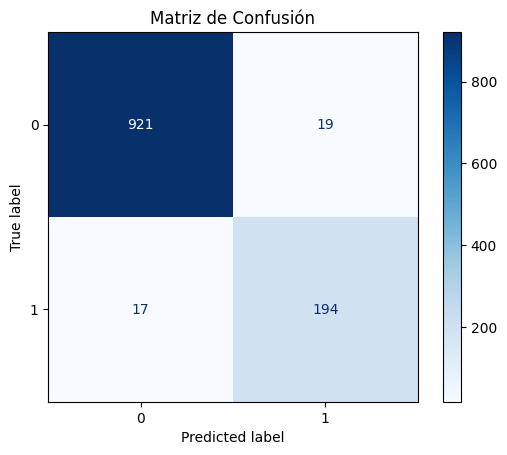

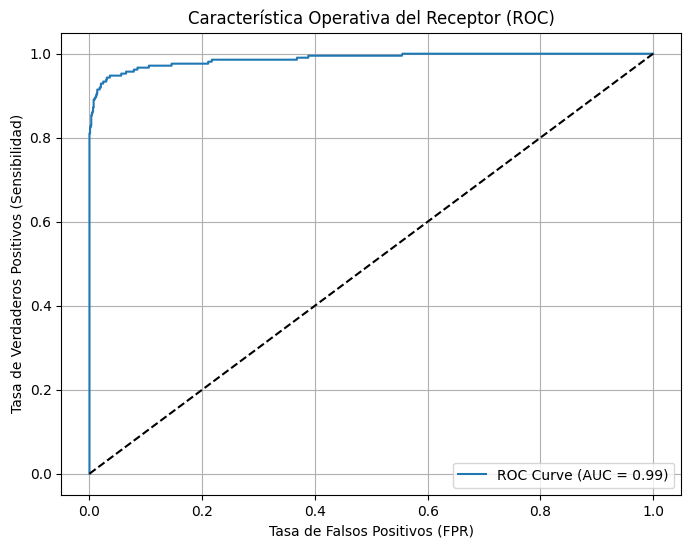

Mejor umbral: 0.6978
Mejor F1-Score: 0.9261


In [27]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix as confussion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import f1_score

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confussion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión")
plt.show()

y_scores = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc = roc_auc_score(y_test, y_scores)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Característica Operativa del Receptor (ROC)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

f1_scores = []
for th in thresholds:
    y_pred_th = (y_scores >= th).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_th))

best_f1_index = np.argmax(f1_scores)
best_threshold = thresholds[best_f1_index]
best_f1 = f1_scores[best_f1_index]

print(f'Mejor umbral: {best_threshold:.4f}')
print(f'Mejor F1-Score: {best_f1:.4f}')



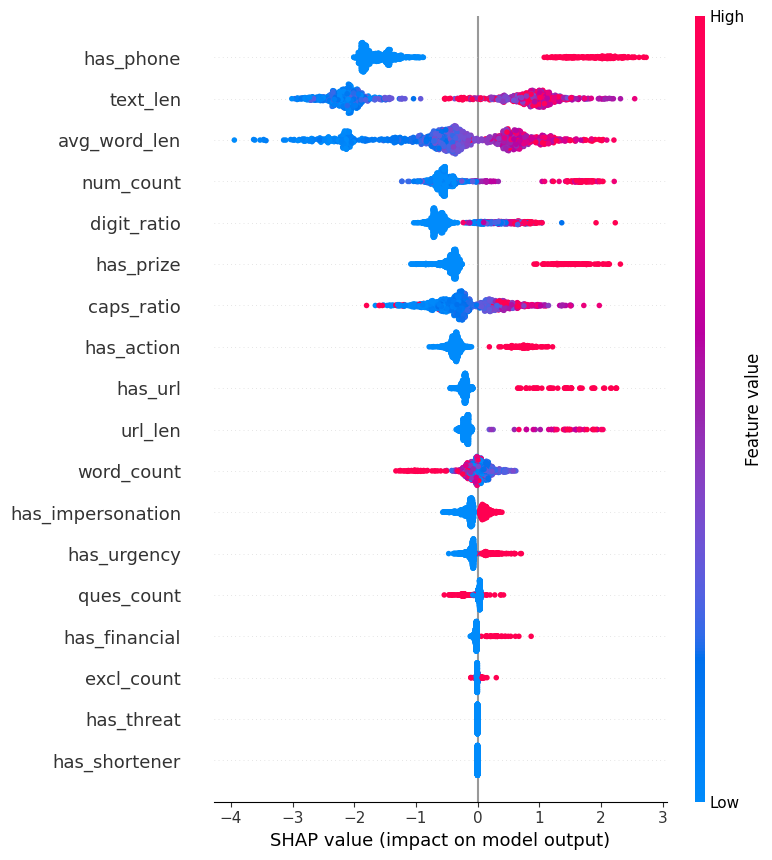

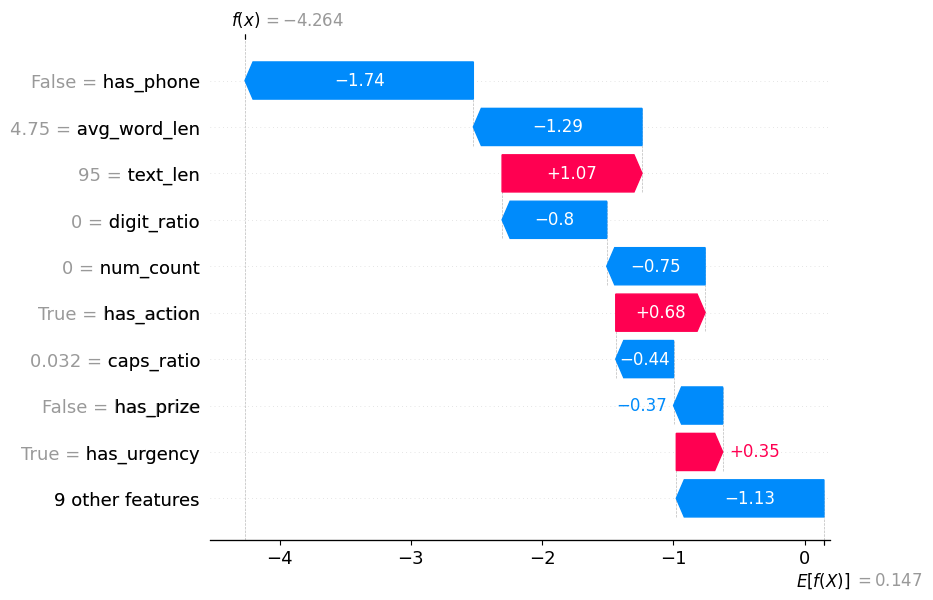

In [35]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

instance_shap = shap_values[0]
shap.plots.waterfall(instance_shap, show=True)

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       940
           1       0.96      0.89      0.93       211

    accuracy                           0.97      1151
   macro avg       0.97      0.94      0.96      1151
weighted avg       0.97      0.97      0.97      1151



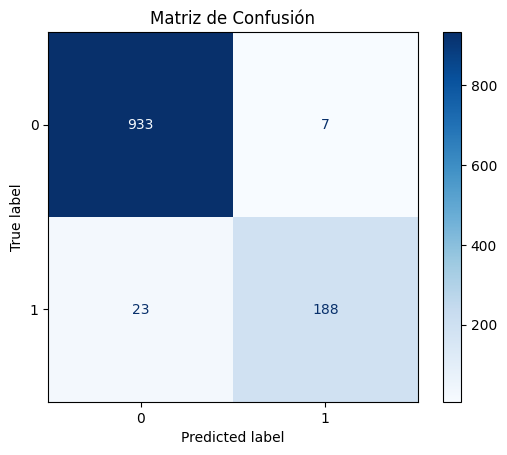

In [39]:
y_pred_optimal = (y_scores >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_optimal))

cm = confussion_matrix(y_test, y_pred_optimal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión")
plt.show()

#Es mejor el umbral anterior, porque genera menos falsos negativos

best_threshold = 0.5


In [43]:
import joblib
import json

from google.colab import drive
drive.mount('/content/drive')
ruta_carpeta = '/content/drive/MyDrive/TFG_Posdata/models/lgbm_v1/'

nombre_modelo = 'model.pkl'
with open(ruta_carpeta + nombre_modelo, 'wb') as f:
  joblib.dump(model, f)
print("Modelo guardado con éxito")

nombre_config = 'config.json'
config = {
    "threshold": best_threshold,
    "features": X.columns.tolist(),
    "model_version": "lgbm_v1"
}
with open(ruta_carpeta + nombre_config, 'w') as f:
    json.dump(config, f)
print("Configuración guardada con éxito")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Modelo guardado con éxito
Configuración guardada con éxito
